In [63]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import time

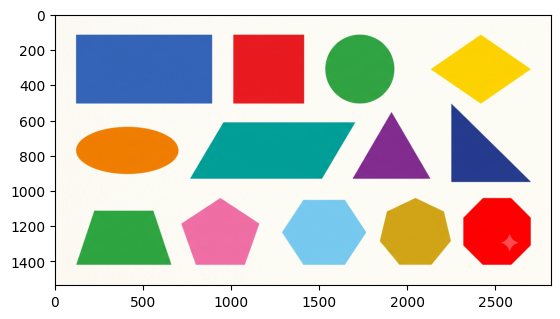

In [11]:
shapes = cv2.imread("shapes.png")
#cv2.imshow("Original Image", shapes)
#cv2.waitKey(0)
#cv2.destroyAllWindows()
plt.imshow(shapes[:, :, ::-1])

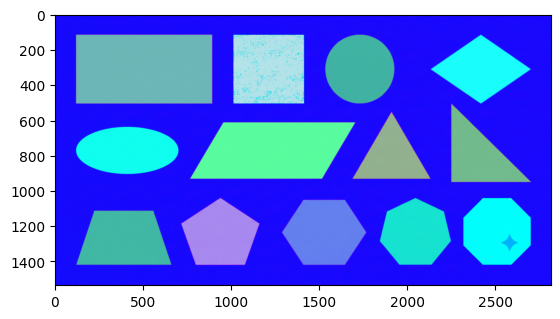

In [34]:
plt.imshow(shapes_hsv, cmap = 'hsv')

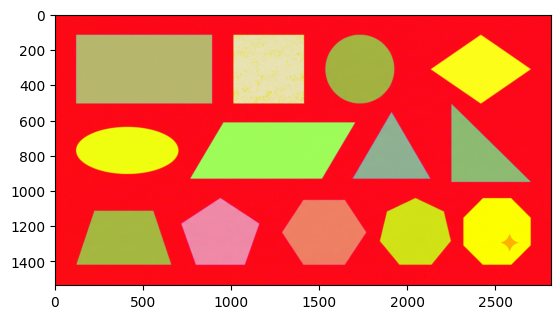

In [28]:
shapes_hsv = cv2.cvtColor(shapes, cv2.COLOR_BGR2HSV)
plt.imshow(shapes_hsv[:, :, ::-1])

In [32]:
cv2.imshow("HSV", shapes_hsv)
cv2.waitKey(3000)
cv2.destroyAllWindows()

In [36]:
lb = np.array([90, 50, 50])
ub = np.array([130, 255, 255])
raw_mask = cv2.inRange(shapes_hsv, lb, ub)

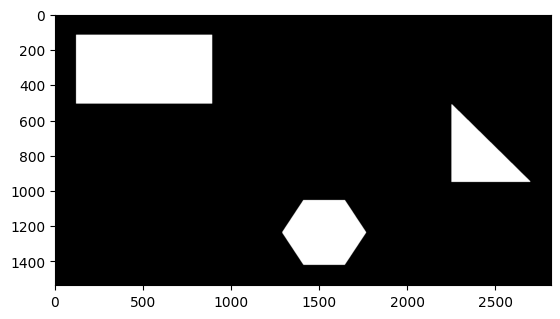

In [48]:
kernel = np.ones((5, 5), dtype = 'uint8')
mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
plt.imshow(mask, cmap = 'gray')

In [46]:
cv2.imshow("Mask", mask)
cv2.waitKey(0)
cv2.destroyAllWindows()

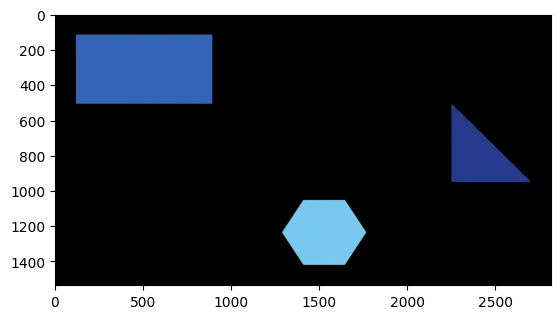

In [42]:
blue_only = cv2.bitwise_and(shapes, shapes, mask = mask)

plt.imshow(blue_only[:, :, ::-1])

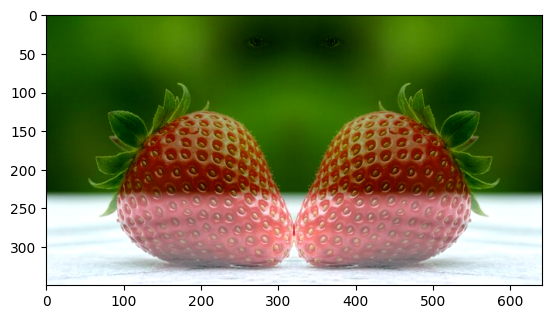

In [61]:
#Experimenting with few functions
img1 = cv2.imread('strawberry.jpg')
img2 = cv2.imread('strawberry.jpg')
img2 = cv2.flip(img2, 1)

combined = cv2.addWeighted(img1, 0.7, img2, 0.7, -50)
plt.imshow(combined[:, :, ::-1])

# Real time Invisibiltity Cloak

In [69]:
cap = cv2.VideoCapture(0)

print("Capturing the background...")
time.sleep(2)

for i in range(30):
    ret, background = cap.read()

if not ret:
    print("Error!! Could not capture the background frame")
    cap.release()
    exit()

background = cv2.flip(background, 1)
print("Background Captured! Now you can hold a RED cloth in front of the camera")

while True:
    ret, frame = cap.read()

    frame = cv2.flip(frame, 1)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    #low_red1 = np.array([0, 120, 70])
    #up_red1 = np.array([10, 255, 255])
    #mask1 = cv2.inRange(hsv, low_red1, up_red1)

    #low_red2 = np.array([170, 120, 70])
    #up_red2 = np.array([180, 255, 255])
    #mask2 = cv2.inRange(hsv, low_red2, up_red2)

    #red_mask = mask1 + mask2

    lowerb = np.array([0, 0, 0], dtype = 'uint8')
    upperb = np.array([180, 255, 70], dtype = 'uint8')
    black_mask = cv2.inRange(hsv, lowerb, upperb)

    kernel = np.ones((3, 3), dtype = 'uint8')
    black_mask = cv2.morphologyEx(black_mask, cv2.MORPH_OPEN, kernel, iterations = 2)
    black_mask = cv2.dilate(black_mask, kernel, iterations = 1)

    inverted_mask = cv2.bitwise_not(black_mask)

    content = cv2.bitwise_and(frame, frame, mask = inverted_mask)

    background = cv2.bitwise_and(background, background, mask = black_mask)

    combined = cv2.addWeighted(content, 1, background, 1, 0)

    cv2.imshow("Invisible Cloak Effect", combined)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

print("Quiting....")
cap.release()
cv2.destroyAllWindows()

Capturing the background...
Background Captured! Now you can hold a RED cloth in front of the camera
Quiting....


In [73]:
cap = cv2.VideoCapture(0)

print("Capturing the background...")
time.sleep(2)

# Warm up camera & capture static background
for i in range(30):
    ret, background = cap.read()

if not ret:
    print("Error!! Could not capture the background frame")
    cap.release()
    exit()

background = cv2.flip(background, 1)
print("Background Captured! Now hold a BLACK object in front of the camera.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error reading frame from webcam.")
        break

    frame = cv2.flip(frame, 1)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Threshold for Black Color (Low Value/Brightness V <= 70)
    lowerb = np.array([0, 0, 0], dtype='uint8')
    upperb = np.array([180, 255, 70], dtype='uint8')
    black_mask = cv2.inRange(hsv, lowerb, upperb)

    # Clean up noise
    kernel = np.ones((3, 3), dtype='uint8')
    black_mask = cv2.morphologyEx(black_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    black_mask = cv2.dilate(black_mask, kernel, iterations=1)

    inverted_mask = cv2.bitwise_not(black_mask)

    # 1. Extract non-black live webcam content
    content = cv2.bitwise_and(frame, frame, mask=inverted_mask)

    # 2. FIX: Save to `bg_portion` instead of overwriting `background`
    bg_portion = cv2.bitwise_and(background, background, mask=black_mask)

    # 3. Combine live non-black content with static background replacement
    combined = cv2.addWeighted(content, 1, bg_portion, 1, 0)

    cv2.imshow("Invisible Cloak Effect (Black)", combined)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

print("Quitting....")
cap.release()
cv2.destroyAllWindows()

Capturing the background...
Background Captured! Now hold a BLACK object in front of the camera.
Quitting....


Hue Spectrum in OpenCV (0 to 179):\
   ┌───────────┬──────────┬──────────┬──────────┬───────────┐\
   │ Red/Orange│  Yellow  │  Green   │   Blue   │ Violet/Red│\
   │  0 - 25   │ 25 - 35  │ 35 - 85  │ 85 - 135 │135 - 179  │\
   └───────────┴──────────┴──────────┴──────────┴───────────┘

In [84]:
spectrum = {
    "r" : [np.array([0, 120, 70]), np.array([10, 255, 255]), np.array([170, 120, 70]), np.array([180, 255, 255])],
    "o" : [np.array([10, 120, 70]), np.array([25, 255, 255])],
    "y" : [np.array([25, 120, 70]), np.array([25, 255, 255])],
    "g" : [np.array([35, 120, 70]), np.array([85, 255, 255])],
    "b" : [np.array([85, 120, 70]), np.array([135, 255, 255])],
    "v" : [np.array([135, 120, 70]), np.array([170, 255, 255])],
}

In [96]:
cap = cv2.VideoCapture(0)

print("Capturing the background...")
time.sleep(2)

# Warm up camera & capture static background
for i in range(30):
    ret, background = cap.read()

if not ret:
    print("Error!! Could not capture the background frame")
    cap.release()
    exit()

background = cv2.flip(background, 1)
print("Background Captured! Now hold a BLACK object in front of the camera.")
print("""Controls:
=============
For Color->
r => Red
b => Blue
g => Green
y => Yellow
o => Orange
v => Violet
=============
Default Green(g)
=============
To exit press q""")

color = "Green"
default = spectrum.get('g')
lowerb = default[0]
upperb = default[1]

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error reading frame from webcam.")
        break

    frame = cv2.flip(frame, 1)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    if color != 'Red':
        mask = cv2.inRange(hsv, lowb, upb)
        current_mask = mask
    else:
        current_mask = mask
        
    current_color = color
            
    # Clean up noise
    kernel = np.ones((3, 3), dtype='uint8')
    current_mask = cv2.morphologyEx(current_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    current_mask = cv2.dilate(current_mask, kernel, iterations=1)

    inverted_mask = cv2.bitwise_not(current_mask)

    # 1. Extract non-black live webcam content
    content = cv2.bitwise_and(frame, frame, mask=inverted_mask)

    # 2. FIX: Save to `bg_portion` instead of overwriting `background`
    bg_portion = cv2.bitwise_and(background, background, mask=current_mask)

    # 3. Combine live non-black content with static background replacement
    combined = cv2.addWeighted(content, 1, bg_portion, 1, 0)

    cv2.putText(combined, f"Current Cloth color:{current_color}", (0, 20), cv2.FONT_HERSHEY_COMPLEX, 0.7, (0, 255, 0), 2)

    cv2.imshow("Invisible Cloak Effect (Black)", combined)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('r'):
        color = 'Red'
        red = spectrum.get("r")
        lowb1 = red[0]
        upb1 = red[1]
        mask1 = cv2.inRange(hsv, lowb1, upb1)

        lowb2 = red[2]
        upb2 = red[3]
        mask2 = cv2.inRange(hsv, lowb2, upb2)

        mask = mask1 + mask2

    elif key == ord('o'):
        color = 'Orange'
        orange = spectrum.get('o')
        lowb = orange[0]
        upb = orange[1]
        #mask = cv2.inRange(hsv, lowb, upb)

    elif key == ord('y'):
        color = 'Yellow'
        yellow = spectrum.get('y')
        lowb = yellow[0]
        upb = yellow[1]
        #mask = cv2.inRange(hsv, lowb, upb)

    elif key == ord('g'):
        color = 'Green'
        green = spectrum.get('g')
        lowb = green[0]
        upb = green[1]
        #mask = cv2.inRange(hsv, lowb, upb)
    
    elif key == ord('b'):
        color = 'Blue'
        blue = spectrum.get('b')
        lowb = blue[0]
        upb = blue[1]
        #mask = cv2.inRange(hsv, lowb, upb)
    
    elif key == ord('v'):
        color = 'Violet'
        violet = spectrum.get('v')
        lowb = violet[0]
        upb = violet[1]
        #mask = cv2.inRange(hsv, lowb, upb)

    elif key == ord('q'):
        break
        

print("Quitting....")
cap.release()
cv2.destroyAllWindows()

Capturing the background...
Background Captured! Now hold a BLACK object in front of the camera.
Controls:
For Color->
r => Red
b => Blue
g => Green
y => Yellow
o => Orange
v => Violet
Default Green(g)
To exit press q
Quitting....


In [9]:
import cv2
import numpy as np
import time

# 1. Define HSV ranges for each color option
# Note: Red requires two ranges because Hue wraps around 0 and 180 in OpenCV
spectrum = {
    'r': [
        (np.array([0, 120, 70]), np.array([10, 255, 255])),
        (np.array([170, 120, 70]), np.array([180, 255, 255]))
    ],
    'o': [(np.array([11, 120, 70]), np.array([25, 255, 255]))],
    'y': [(np.array([26, 120, 70]), np.array([35, 255, 255]))],
    'g': [(np.array([36, 120, 70]), np.array([85, 255, 255]))],
    'b': [(np.array([86, 120, 70]), np.array([135, 255, 255]))],
    'v': [(np.array([136, 120, 70]), np.array([169, 255, 255]))]
}

cap = cv2.VideoCapture(0)

print("Capturing the background...")
time.sleep(2)

# Warm up camera & capture static background
for i in range(30):
    ret, background = cap.read()

if not ret:
    print("Error!! Could not capture the background frame")
    cap.release()
    exit()

background = cv2.flip(background, 1)

print("""Controls:
=============
r => Red
o => Orange
y => Yellow
g => Green (Default)
b => Blue
v => Violet
q => Exit
=============
""")

# Default starting color
active_key = 'g'
color_name = "Green"

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error reading frame from webcam.")
        break

    frame = cv2.flip(frame, 1)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 2. Dynamically compute mask for the active color on EVERY frame
    if active_key == 'r':
        # Combine two red HSV ranges
        bounds = spectrum['r']
        mask1 = cv2.inRange(hsv, bounds[0][0], bounds[0][1])
        mask2 = cv2.inRange(hsv, bounds[1][0], bounds[1][1])
        current_mask = mask1 + mask2
    else:
        bounds = spectrum[active_key][0]
        current_mask = cv2.inRange(hsv, bounds[0], bounds[1])

    # 3. Clean up noise
    kernel = np.ones((3, 3), dtype='uint8')
    current_mask = cv2.morphologyEx(current_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    current_mask = cv2.dilate(current_mask, kernel, iterations=1)

    inverted_mask = cv2.bitwise_not(current_mask)

    # 4. Extract non-cloth content and background replacement
    content = cv2.bitwise_and(frame, frame, mask=inverted_mask)
    bg_portion = cv2.bitwise_and(background, background, mask=current_mask)

    # 5. Blend images
    combined = cv2.addWeighted(content, 1, bg_portion, 1, 0)

    # Overlay current status text
    cv2.putText(combined, f"Active Color: {color_name}", (10, 30), 
                cv2.FONT_HERSHEY_COMPLEX, 0.7, (0, 255, 0), 2)

    cv2.imshow("Multi-Color Invisibility Cloak", combined)

    # 6. Keypress listener ONLY updates active_key state
    key = cv2.waitKey(1) & 0xFF

    if key == ord('r'):
        active_key, color_name = 'r', 'Red'
    elif key == ord('o'):
        active_key, color_name = 'o', 'Orange'
    elif key == ord('y'):
        active_key, color_name = 'y', 'Yellow'
    elif key == ord('g'):
        active_key, color_name = 'g', 'Green'
    elif key == ord('b'):
        active_key, color_name = 'b', 'Blue'
    elif key == ord('v'):
        active_key, color_name = 'v', 'Violet'
    elif key == ord('q'):
        break

print("Quitting....")
cap.release()
cv2.destroyAllWindows()

Capturing the background...
Controls:
r => Red
o => Orange
y => Yellow
g => Green (Default)
b => Blue
v => Violet
q => Exit

Quitting....
